## Bernstein-Vazirani
Descubre un **número secreto** `s` (donde f(x) = s·x) con una sola consulta.
El resultado de la medición ES el secreto.

In [2]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Operator
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

sim = AerSimulator()

def correr(qc, shots=1024):
    """Ejecuta un circuito en el simulador y devuelve los conteos."""
    return sim.run(transpile(qc, sim), shots=shots).result().get_counts()

Secreto: 101101 | Medido: {'101101': 1024}


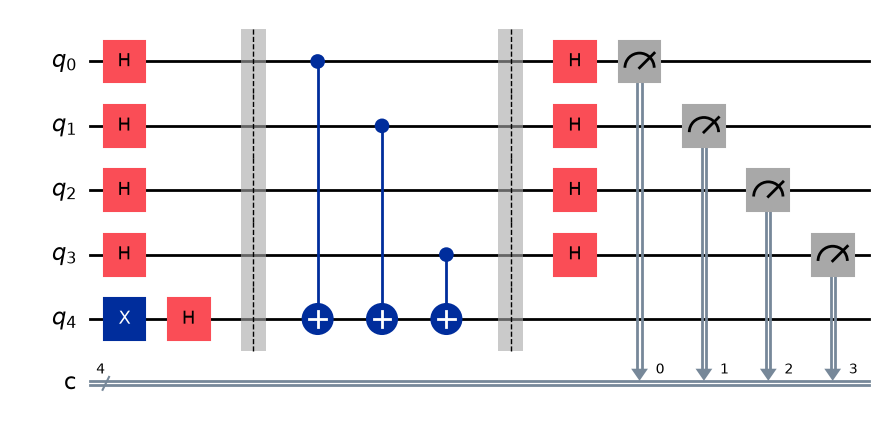

In [3]:
def bernstein_vazirani(secreto):
    n = len(secreto)
    qc = QuantumCircuit(n + 1, n)
    qc.x(n); qc.h(range(n + 1))
    qc.barrier()
    for i, bit in enumerate(reversed(secreto)):   # qubit i <-> bit i del secreto
        if bit == "1":
            qc.cx(i, n)
    qc.barrier()
    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc

secreto = "101101"
print("Secreto:", secreto, "| Medido:", correr(bernstein_vazirani(secreto)))
bernstein_vazirani("1011").draw("mpl")